# import

In [2]:
import sys
sys.path.append('..')
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import seaborn as sns
import plotly.express as px
from pathlib import Path
from StatTools.analysis.dfa import DFA, dfa, dfa_worker
import scipy.stats as stats

In [3]:
def _detrend_segment(y_segment: np.ndarray, indices: np.ndarray, degree: int) -> np.ndarray:
        """
        Compute detrended residuals for a single segment.

        Args:
            y_segment: Integrated time series segment.
            indices: Indices for polynomial fitting.
            degree: Polynomial degree for detrending.

        Returns:
            Residuals (detrended segment).
        """
        coef = np.polyfit(indices, y_segment, deg=degree)
        trend = np.polyval(coef, indices)
        residuals = y_segment - trend
        return residuals

In [4]:
from typing import Union
def dfa_worker(
    indices: Union[int, list, np.ndarray],
    arr: Union[np.ndarray, None] = None,
    degree: int = 2,
    s_values: Union[list, np.ndarray, None] = None,
    n_integral: int = 1,
) -> list:
    """
    Core of the DFA algorithm. Processes a subset of series (indices) and
    returns fluctuation functions F^2(s).

    Args:
        indices: Indices of time series in the dataset to process.
        arr: Dataset array (must be 2D, shape: (n_series, length)).
        degree: Polynomial degree for detrending.
        s_values: Pre-calculated box sizes (scales).
        n_integral: Number of cumulative sum operations to apply (default: 1).

    Returns:
        list of (s, F2_s) for each requested index, where F2_s is F^2(s).
    """


    data = np.asarray(arr, dtype=float)

    if data.ndim != 2:
        raise ValueError(
            f"dfa_worker expects 2D array, got {data.ndim}D array. "
            f"Normalize data to 2D before calling (use reshape(1, -1) for 1D)."
        )

    if not isinstance(indices, (list, np.ndarray)):
        indices = [indices]

    series_len_global = data.shape[1]
    if s_values is None:
        s_max = int(series_len_global / 4)
        s_values = [int(np.exp(step)) for step in np.arange(1.6, np.log(s_max), 0.5)]
    else:
        s_values = list(s_values)

    results = []

    for idx in indices:
        series = data[idx]

        # Standard DFA preprocessing: mean-centering and integration
        data_centered = series - np.mean(series)
        y_cumsum = data_centered
        for _ in range(n_integral):
            y_cumsum = np.cumsum(y_cumsum)
        series_len = len(data_centered)

        s_list = []
        f2_list = []

        for s_val in s_values:
            if s_val >= series_len / 4:
                continue

            s = np.arange(1, s_val + 1, dtype=int)
            len_s = len(s)
            cycles_amount = np.floor(series_len / len_s)
            if cycles_amount < 1:
                continue

            f2_sum = 0.0
            s_temp = s.copy()

            for i in range(1, cycles_amount):
                indices_s = (s_temp - (i + 0.5) * len_s).astype(int)
                y_cumsum_s = y_cumsum[s_temp]

                # Compute detrended residuals for this segment
                residuals = _detrend_segment(y_cumsum_s, indices_s, degree)

                # Mean squared residual in the window
                f2 = np.sum(residuals**2) / len_s

                # Accumulate mean squared residuals to get F^2(s)
                f2_sum += f2
                s_temp += s_val

            # Fluctuation function F^2(s)
            f2_s = f2_sum / cycles_amount
            s_list.append(s_val)
            f2_list.append(f2_s)

        results.append((np.array(s_list), np.array(f2_list)))

    return results

# qq analysis

In [7]:
pyeensis_dict = dict()

pyeensis_dir  = Path(r'../data/pyeensis')
pbar = tqdm(pyeensis_dir.glob("*.csv"), total=len(list(pyeensis_dir.glob("*.csv"))))
overall_disp = []
for path in pbar:
    df = pd.read_csv(path)
    trajs = df[['track_id', 'x', 'y']]
    
    disp = trajs.groupby('track_id').diff().dropna().melt()['value']
    overall_disp.append(disp)
overall_disp_pyeensis = pd.concat(overall_disp)

100%|██████████| 45/45 [00:08<00:00,  5.06it/s]


<Axes: xlabel='value', ylabel='Density'>

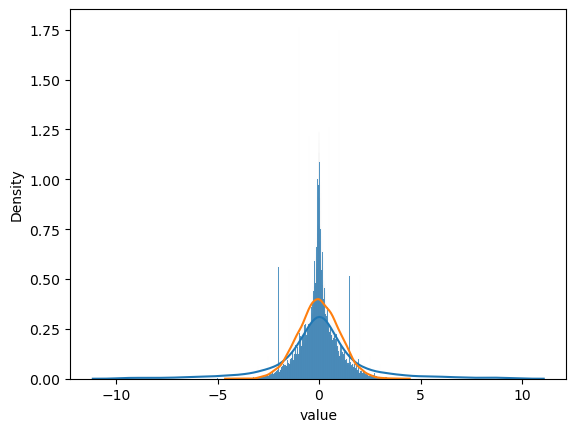

In [15]:
cauchy = np.random.standard_cauchy(10000)
cauchy = cauchy[np.abs(cauchy)<10]
sns.histplot(overall_disp_pyeensis[(overall_disp_pyeensis!=0)&(np.abs(overall_disp_pyeensis)<10)], stat='density')
sns.kdeplot(cauchy)
sns.kdeplot(np.random.standard_normal(10000))

In [ ]:
# emp = []
# teor = []
# cauchy = np.random.standard_cauchy(10000)
# cauchy = cauchy[np.abs(cauchy)<100]
# for q in np.linspace(0.01, 0.99, 50):
#     emp.append(np.quantile(overall_disp_pyeensis, q))
#     teor.append(np.quantile(cauchy, q))
# quant = pd.DataFrame([emp, teor]).T

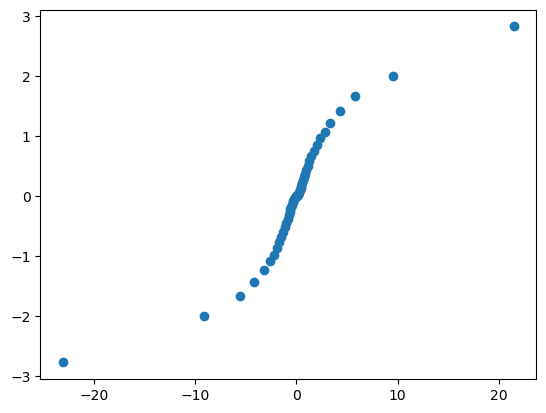

In [ ]:
# plt.scatter(teor, emp)

((array([-35156741.00665168, -14483682.59142638,  -9084360.0969524 , ...,
           9084360.12613109,  14483682.66331408,  35156741.00665168],
        shape=(76556830,)),
  array([-685.95988464, -607.2928772 , -604.70350647, ...,  382.83679962,
          399.99927521,  434.04341888], shape=(76556830,))),
 (np.float64(4.179020240687017e-05),
  np.float64(-0.0006501631454996879),
  np.float64(0.18307847305567107)))

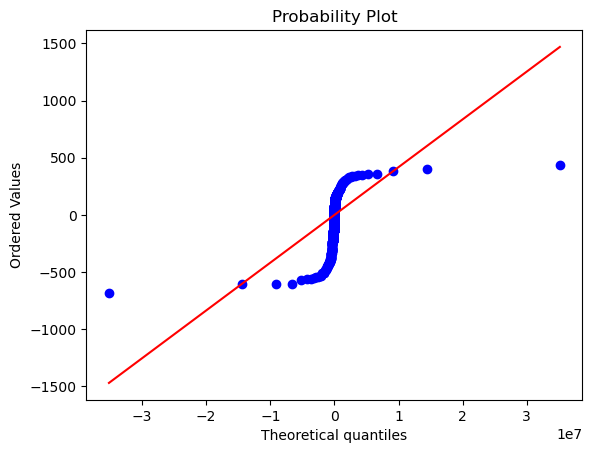

In [68]:
stats.probplot(overall_disp_pyeensis, dist=stats.cauchy, plot=plt)

In [5]:
df = pd.read_csv('../data/kalman_bag_test.csv')
trajs = df[['track_id', 'x', 'y']]
    
disp = trajs.groupby('track_id').diff().dropna().melt()['value']
cauchy = np.random.standard_cauchy(10000)*0.35
cauchy = cauchy[np.abs(cauchy)<10]

<Axes: xlabel='value', ylabel='Density'>

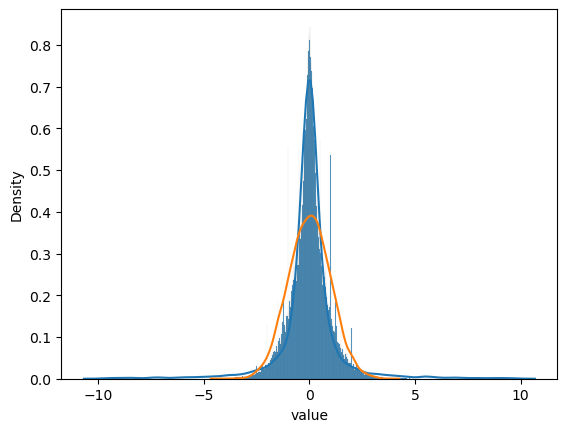

In [9]:
sns.histplot(disp[disp!=0], stat='density')
sns.kdeplot(cauchy)
sns.kdeplot(np.random.standard_normal(10000))

# ff 

In [74]:
df = pd.read_csv('../data/kalman_bag_test.csv')
trajs = df[['track_id', 'x', 'y']]

In [119]:
resid_dist_overall_series = defaultdict(list)
for _, trajectory in tqdm(trajs.groupby('track_id', group_keys=False)):
    trajectory = trajectory.drop(columns='track_id')
    s_values = [int(np.exp(step)) for step in np.arange(np.log(6), np.log(len(trajectory)//4), 0.4)]
    for col in ['x', 'y']:
        series = trajectory[col].values
        
        # Standard DFA preprocessing: mean-centering and integration
        data_centered = series - np.mean(series)
        y_cumsum = data_centered
        for _ in range(1):
            y_cumsum = np.cumsum(y_cumsum)
        series_len = len(data_centered)

        s_list = []
        f2_list = []
        
        for s_val in s_values:
            if s_val >= series_len / 4:
                continue

            s = np.arange(1, s_val + 1, dtype=int)
            len_s = len(s)
            cycles_amount = np.floor(series_len / len_s).astype(int)
            if cycles_amount < 1:
                continue

            f2_sum = 0.0
            s_temp = s.copy()
            resid_dist_for_s_value = []
            for i in range(1, cycles_amount):
                indices_s = (s_temp - (i + 0.5) * len_s).astype(int)
                y_cumsum_s = y_cumsum[s_temp]

                # Compute detrended residuals for this segment
                residuals = _detrend_segment(y_cumsum_s, indices_s, 2)
                resid_dist_for_s_value.extend(residuals)
            #     # Mean squared residual in the window
            #     f2 = np.sum(residuals**2) / len_s

            #     # Accumulate mean squared residuals to get F^2(s)
            #     f2_sum += f2
            #     s_temp += s_val

            # # Fluctuation function F^2(s)
            # f2_s = f2_sum / cycles_amount
            # s_list.append(s_val)
            # f2_list.append(f2_s)
            resid_dist_overall_series[s_val].extend(resid_dist_for_s_value)

 99%|█████████▊| 9622/9766 [00:19<00:00, 683.03it/s]/tmp/ipykernel_845217/545247788.py:4: RuntimeWarning: divide by zero encountered in log
  s_values = [int(np.exp(step)) for step in np.arange(np.log(6), np.log(len(trajectory)//4), 0.4)]
100%|█████████▉| 9765/9766 [00:19<00:00, 488.51it/s]


ValueError: Maximum allowed size exceeded

In [135]:
df_long = pd.DataFrame(
    [
        {"s_values": key, "resid": value}
        for key, values in resid_dist_overall_series.items()
        for value in values
    ]
)

/home/akhiyarov/.conda/envs/asdc/lib/python3.12/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/home/akhiyarov/.conda/envs/asdc/lib/python3.12/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


<Axes: xlabel='s_values', ylabel='resid'>

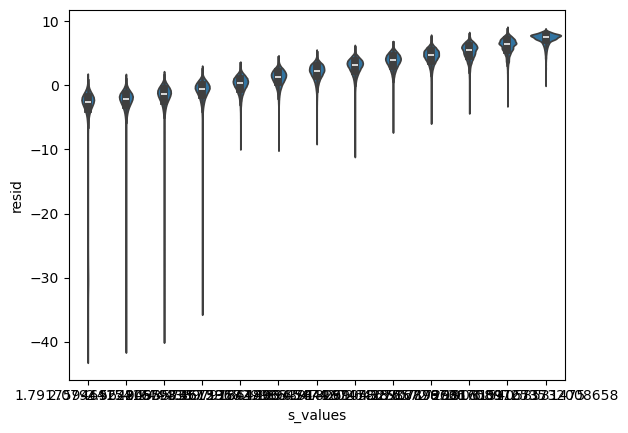

In [136]:
sns.violinplot(np.log(df_long), x='s_values', y='resid')

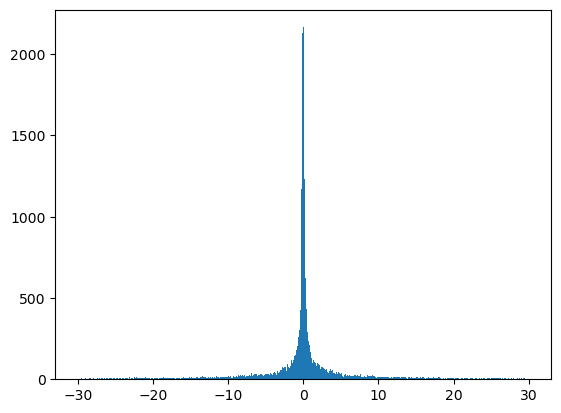

In [65]:
plt.hist(np.concat(resid_dist_overall_series), bins=500, range=(-30, 30))
plt.show()

In [66]:
resids = pd.DataFrame(resid_dist_overall_series).T

In [78]:
from StatTools.analysis.utils import analyse_zero_cross_ff

In [82]:
ff_params, _ = analyse_zero_cross_ff(resids.abs().sum(axis=0).values, s_values)

In [83]:
ff_params

ff_params(intercept=var_estimation(value=np.float64(0.018898338268955595), stderr=np.float64(0.042306535286633876)), cross=[], slopes=[var_estimation(value=np.float64(2.1439009694390156), stderr=np.float64(0.026923290672797553))], ridigity=[])

ValueError: x and y must have same first dimension, but have shapes (32,) and (35,)

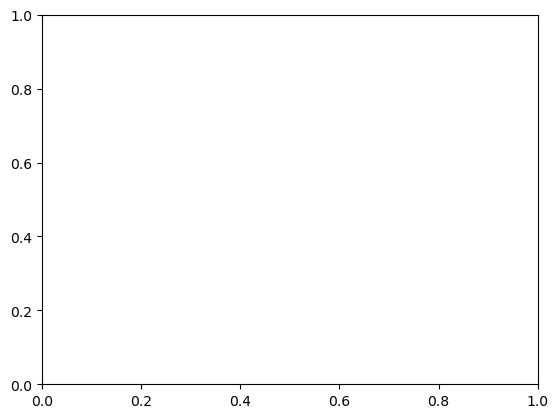

In [109]:
plt.plot(s_values, resids.abs().sum(axis=0))
plt.xscale('log')
plt.yscale('log')

/home/akhiyarov/.conda/envs/asdc/lib/python3.12/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/home/akhiyarov/.conda/envs/asdc/lib/python3.12/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


<Axes: >

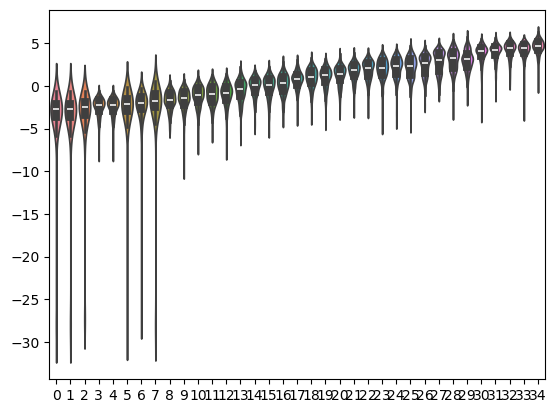